<a href="https://colab.research.google.com/github/ashwiniv07/Journal-paper--DDoS-GT-DL-/blob/main/hping3pcap_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[+] Loaded 258491 packets, time range 0.1 – 120.0 s
    PPS array length: 1200 (expected ~1200)


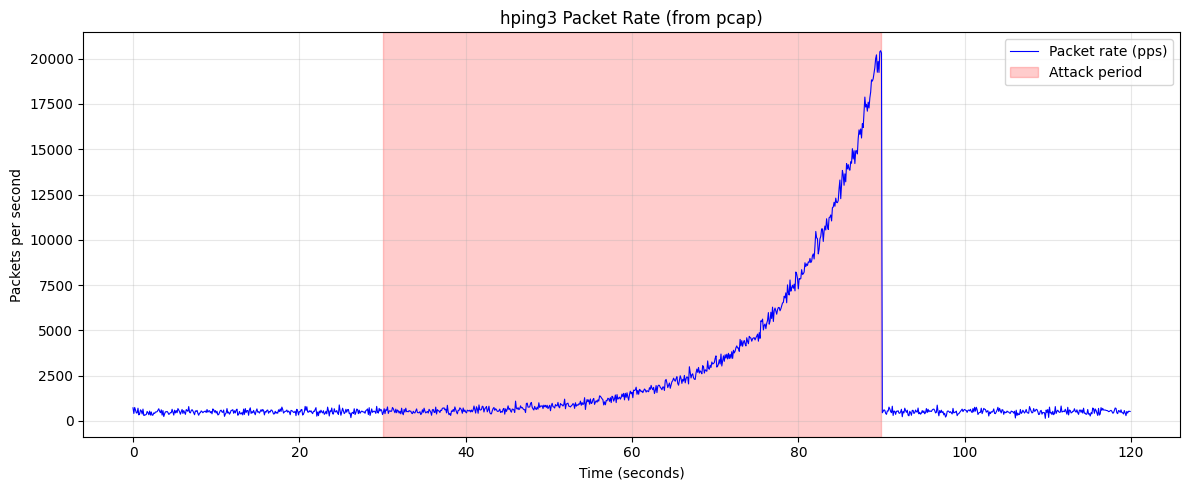

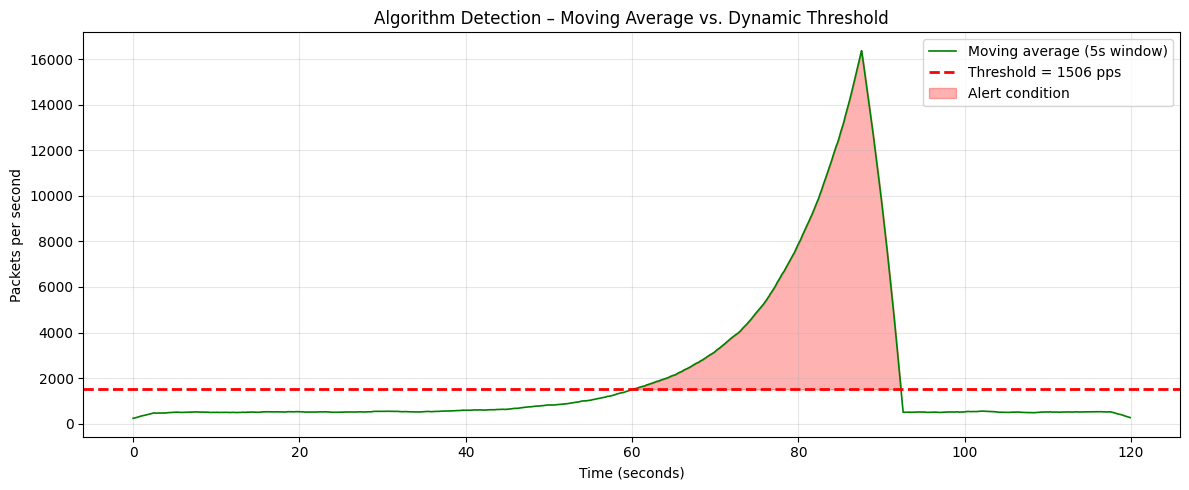

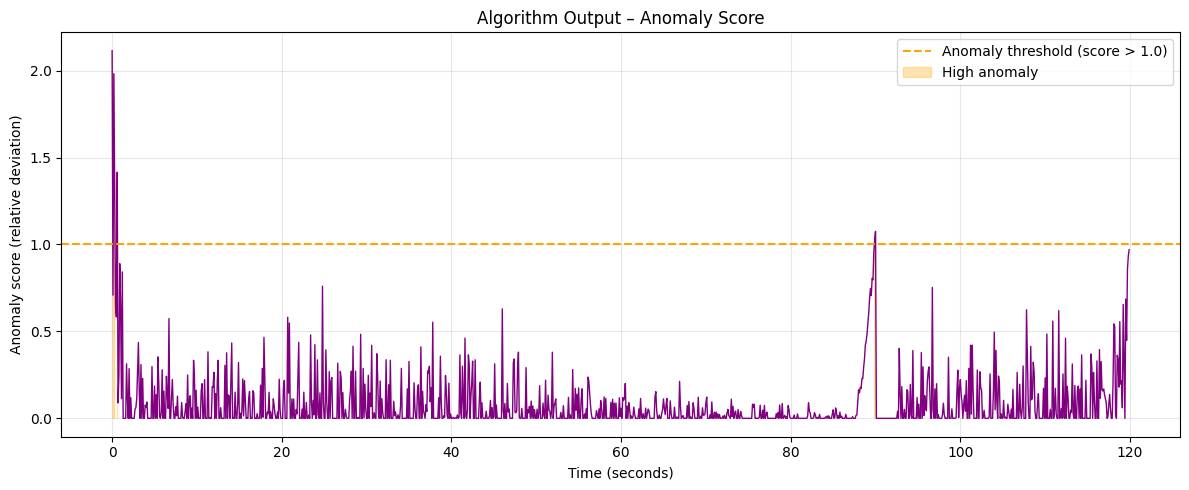

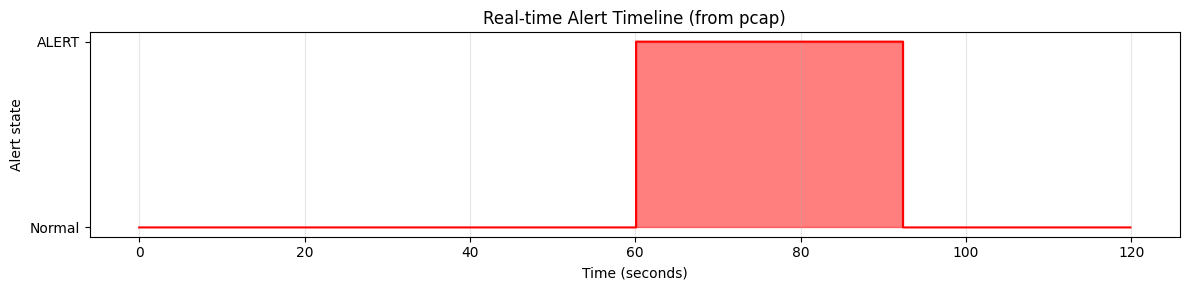


[+] 4 images generated from pcap:
  1_hping3_packet_rate_from_pcap.png
  2_algorithm_moving_avg_threshold_from_pcap.png
  3_algorithm_anomaly_score_from_pcap.png
  4_algorithm_alert_timeline_from_pcap.png


In [ ]:
!pip install scapy
from scapy.all import rdpcap
import numpy as np
import matplotlib.pyplot as plt

pcap_file = "hping_capture.pcap"
packets = rdpcap(pcap_file)
timestamps = [pkt.time for pkt in packets]
start_time = min(timestamps)
relative_times = np.array([t - start_time for t in timestamps])
bin_width = 0.1
max_time = np.ceil(max(relative_times))
bins = np.arange(0, max_time + bin_width, bin_width)
counts, _ = np.histogram(relative_times, bins=bins)
packet_rate = counts / bin_width
time = bins[:-1]
if len(time) > 1200:
    time = time[:1200]
    packet_rate = packet_rate[:1200]
attack_start = 30
attack_end = 90
window_samples = int(5 / bin_width)
moving_avg = np.convolve(packet_rate, np.ones(window_samples)/window_samples, mode='same')
baseline_end_idx = int(attack_start / bin_width)
baseline_estimate = np.mean(packet_rate[:baseline_end_idx])
threshold = baseline_estimate * 3
anomaly_score = (packet_rate - moving_avg) / moving_avg
anomaly_score = np.clip(anomaly_score, 0, 10)
alert = moving_avg > threshold
plt.figure(figsize=(12, 5))
plt.plot(time, packet_rate, linewidth=0.8, color='blue', label='Packet rate (pps)')
plt.axvspan(attack_start, attack_end, alpha=0.2, color='red', label='Attack period')
plt.xlabel('Time (seconds)')
plt.ylabel('Packets per second')
plt.title('hping3 Packet Rate (from pcap)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('1_hping3_packet_rate_from_pcap.png', dpi=150)
plt.show()
plt.figure(figsize=(12, 5))
plt.plot(time, moving_avg, linewidth=1.2, color='green', label='Moving average (5s window)')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold:.0f} pps')
plt.fill_between(time, threshold, moving_avg, where=(moving_avg > threshold),
                 color='red', alpha=0.3, label='Alert condition')
plt.xlabel('Time (seconds)')
plt.ylabel('Packets per second')
plt.title('Algorithm Detection – Moving Average vs. Dynamic Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('2_algorithm_moving_avg_threshold_from_pcap.png', dpi=150)
plt.show()
plt.figure(figsize=(12, 5))
plt.plot(time, anomaly_score, linewidth=1.0, color='purple')
plt.axhline(y=1.0, color='orange', linestyle='--', label='Anomaly threshold (score > 1.0)')
plt.fill_between(time, 0, anomaly_score, where=(anomaly_score > 1.0),
                 color='orange', alpha=0.3, label='High anomaly')
plt.xlabel('Time (seconds)')
plt.ylabel('Anomaly score (relative deviation)')
plt.title('Algorithm Output – Anomaly Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('3_algorithm_anomaly_score_from_pcap.png', dpi=150)
plt.show()
plt.figure(figsize=(12, 3))
alert_signal = np.where(alert, 1, 0)
plt.plot(time, alert_signal, drawstyle='steps-post', color='red', linewidth=1.5)
plt.fill_between(time, 0, alert_signal, where=(alert_signal == 1), color='red', alpha=0.5)
plt.xlabel('Time (seconds)')
plt.ylabel('Alert state')
plt.yticks([0, 1], ['Normal', 'ALERT'])
plt.title('Real‑time Alert Timeline (from pcap)')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('4_algorithm_alert_timeline_from_pcap.png', dpi=150)
plt.show()
print("  1_hping3_packet_rate_from_pcap.png")
print("  2_algorithm_moving_avg_threshold_from_pcap.png")
print("  3_algorithm_anomaly_score_from_pcap.png")
print("  4_algorithm_alert_timeline_from_pcap.png")